# Develop a PSD function for grids

1. a function that calculates the psd of each of the rows (or columns) of a grid, and then averages them to produce a `grid_psd`.
1. Core function does the above on a single 2D array in an xarray. It can be called by a function that reads the xarray from file and passes to the core function.
1. 

In [1]:
import numpy as np
import xarray as xr
import scipy.signal as sig
import matplotlib.pyplot as plt
from matplotlib import rc
%matplotlib widget
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica Neue']})

In [2]:
import sys
sys.path.insert(0, "/Users/markdransfield/Documents/GitHub/AirGravQC")

from pathlib import Path
from AirGravQC import pointfiles as mhd
from AirGravQC import qualityAnalysis as qc
from AirGravQC import whizzPlot as wp
from AirGravQC import gridfiles as grd

In [3]:
def array_psd(data, dim=0, voxwidth=1.0):
    fsample = 1.0 / voxwidth
    if dim == 0:
        nperseg = data.shape[1]
        freq, my_power = sig.welch(data[0,:], fs = fsample, nperseg=nperseg, scaling='density')
        dividend = data.shape[0]
        for i in range(1,dividend):
            freq, Pxx = sig.welch(data[i,:], fs = fsample, nperseg=nperseg, scaling='density')
            my_power = my_power + Pxx
        print("0 ", freq.shape, Pxx.shape, my_power.shape, nperseg, np.max(my_power))
    elif dim == 1:
        nperseg = data.shape[0]
        freq, my_power = sig.welch(data[:,0], fs = fsample, nperseg=nperseg, scaling='density')
        dividend = data.shape[1]
        for i in range(1,dividend):
            freq, Pxx = sig.welch(data[:,i], fs = fsample, nperseg=nperseg, scaling='density')
            my_power = my_power + Pxx
        print("1 ", freq.shape, Pxx.shape, my_power.shape, nperseg, np.max(my_power))
    else:
        print("Error - dim must be 0 or 1.")
        return
    my_power = my_power / dividend # mean power density over rows or cols
    period = 1.0 / freq[2:-1]
    rootPwr = np.sqrt(my_power[2:-1])
    maxPwr = np.max(rootPwr)
    print(f'Low-f limit: {rootPwr[-1]:.2f}, max: {maxPwr:.2f}')
    return period, rootPwr

    
def plot_psd(periods, rootPwrs, labels=[], projectname="", zname="", zunits="", noise_Erootm=30.0):
    if zunits != "":
        zunits += "sqrt(m)"
    if labels == []:
        labels = ["1", "2", "3", "4", "noise", "BW"]

    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)

    count = 0
    for rootPwr in rootPwrs:
        plt.loglog(periods[count], rootPwr, label=labels[count], lw=0.3)
        count +=1
    # plt.loglog(periods[0], 30.0 * np.ones(len(periods[0])), label='noise', lw=0.6, color="red")
    # plt.loglog([330.0, 330.0], [min(rootPwrs[0]), max(rootPwrs[0])], label='BW', lw=0.6, color="red")
    plt.xlabel('Wavelength [m]', fontsize = 8)
    plt.ylabel(f'{zname} {zunits}', fontsize = 8)
    plotTitle = f'{projectname} : {zname}'
    plt.title(plotTitle, fontsize = 8)
    plt.grid(True)
    ax.legend()
    for label in ax.get_xticklabels(): label.set_fontsize(8)
    for label in ax.get_yticklabels(): label.set_fontsize(8)


In [4]:
def prep_for_gridPSD(x1):
    print("input shape ", x1.values.shape)
    m = x1.values.shape[0]
    min_n = 2 * x1.values.shape[1]
    count = 0

    for i in range(0, m):
        a = trim_nans(x1.values[i,:])

        if(np.isnan(a).any()) or len(a) < 128:
            continue
        count += 1
        min_n = min(min_n, len(a))

    out = np.zeros((count, min_n))
    count = 0
    for i in range(0, m):
        a = trim_nans(x1.values[i,:])
        if(np.isnan(a).any()) or len(a) < 128:
            continue
        out[count,:] = a[0:min_n]
        count += 1
    print(f'output shape {out.shape}')
        
    return out

In [5]:
def trim_nans(a):
    start, end = 0, len(a)  
    for x in range(len(a)):
        if a[x] > 0 and start == 0: 
            start = x
            break

    for x in range(len(a)):
        if a[-x] > 0 and end == len(a): 
            end = -x + 1
            break
    return a[start:end]

In [6]:
def trim_to_rect(a, xs, ys):
    return a.values[xs[0]:xs[1],ys[0]:ys[1]]

In [20]:
# grid_root = r'/Volumes/T7/CarlosSep23/'
# ersp = Path(grid_root)
# g1 = Path(grid_root + r'26_Oct2023/2205113_Yerrida_GDD_2p67_Final.ers')
# # g2 = Path(grid_root + r'19_Oct_2023/2205113_AGG_Final_Test01_New_GUV_02.ers')
# g3 = Path(grid_root + r'26_Oct2023/GDD_1_2p67.ers')
# # g4 = Path(grid_root + r'19_Oct_2023/Yerrida_GUV_2p67.ers')

In [7]:
grid_root = r'/Volumes/T7/ActiveSurveys/202206_NSW/Xcal/Conforming Options/'
ersp = Path(grid_root)
g1 = Path(grid_root + r'Curvature Conforming/gD_0p0_curvature_conforming_difference_from_DTU_13.ers')
g2 = Path(grid_root + r'Standard Conforming/gD_0p0_standard_conforming_difference_from_DTU_13.ers')
g3 = Path(grid_root + r'Vertical Conforming/gD_0p0_vertical_conforming_difference_from_DTU_13.ers')
# g2 = Path(grid_root + r'19_Oct_2023/2205113_AGG_Final_Test01_New_GUV_02.ers')
# g3 = Path(grid_root + r'26_Oct2023/GDD_1_2p67.ers')
# g4 = Path(grid_root + r'19_Oct_2023/Yerrida_GUV_2p67.ers')

In [8]:
xa, wf = grd.gridfile_to_xr(whizzFile=g1)
x1 = xa[wf.stem]
xa, wf = grd.gridfile_to_xr(whizzFile=g2)
x2 = xa[wf.stem]
xa, wf = grd.gridfile_to_xr(whizzFile=g3)
x3 = xa[wf.stem]
# xa, wf = grd.gridfile_to_xr(whizzFile=g4)
# x4 = xa[wf.stem]
;

32 bit precision
32 bit precision
32 bit precision


''

In [9]:
x1.shape

(1667, 1827)

In [10]:
x1

<xarray.DataArray 'gD_0p0_curvature_conforming_difference_from_DTU_13' (
                                                                        N: 1667,
                                                                        E: 1827)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ..., -2.2660742, -2.2349072,
        -2.2042918],
       [       nan,        nan,        nan, ..., -2.2819395, -2.250503 ,
        -2.2190895],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], dtype=float32)
Coordinates:
  * N        (N) float32 5.981e+06 5.982e+06 5.982e+06 ... 6.814e+06 6.814e+06
  * E        (E) float32 4.94e+05 4.945e+05 4.95e+05 ... 1.406e+06 1.407e+06

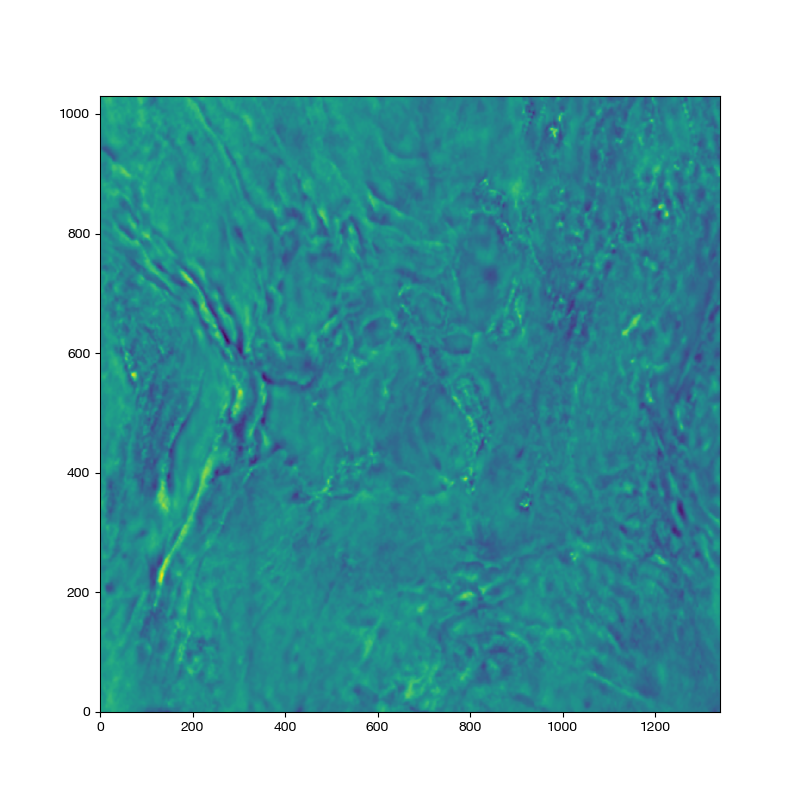

In [16]:
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(1,1,1)
# plt.pcolormesh(x1.values)
plt.pcolormesh(x1.values[70:1100,0:1340])


In [35]:
out1 = trim_to_rect(x1, [75, 1095], [5, 1335])
out2 = trim_to_rect(x2, [75, 1095], [5, 1335])
out3 = trim_to_rect(x3, [75, 1095], [5, 1335])
# out4 = trim_to_rect(x4, [35, 75], [20, 253])

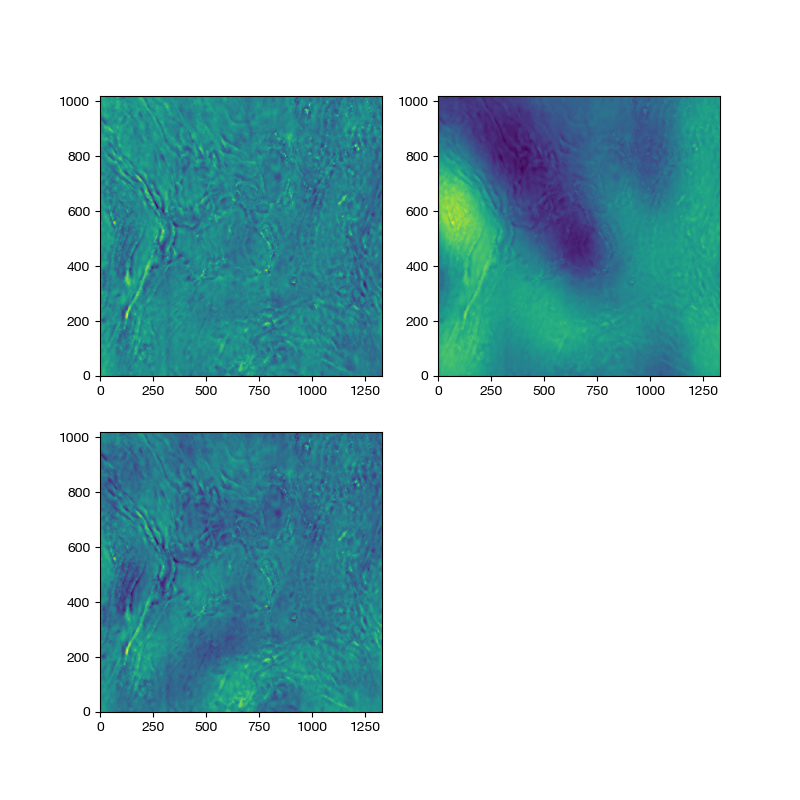

In [36]:
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(2,2,1)
plt.pcolormesh(out1)
ax2 = fig.add_subplot(2,2,2)
plt.pcolormesh(out2)
ax3 = fig.add_subplot(2,2,3)
plt.pcolormesh(out3)
# ax4 = fig.add_subplot(2,2,4)
# plt.pcolormesh(out4)

In [37]:
dim = 1
w1, p1 = array_psd(out1, dim, voxwidth=500.0)
w2, p2 = array_psd(out2, dim, voxwidth=500.0)    
w3, p3 = array_psd(out3, dim, voxwidth=500.0)    
# w4, p4 = array_psd(out4, dim, voxwidth=50.0)    

1  (511,) (511,) (511,) 1020 327705470.0
Low-f limit: 0.10, max: 480.13
1  (511,) (511,) (511,) 1020 51044504000.0
Low-f limit: 0.10, max: 3925.77
1  (511,) (511,) (511,) 1020 1160765700.0
Low-f limit: 0.09, max: 934.21


In [33]:
def test(out1):
    freq, Pxx = sig.welch(out1[0,:], fs = 0.002, nperseg=out1.shape[1], scaling='density')
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    plt.loglog(freq, Pxx)


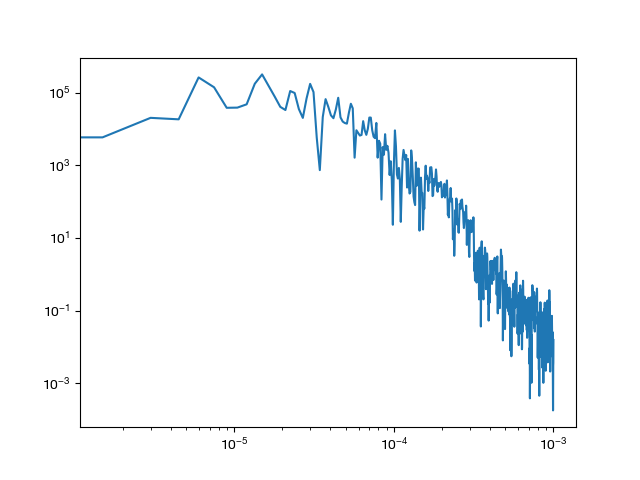

In [34]:
test(out1)

In [31]:
# plot_psd([w1, w2, w3, w4], [p1, p2, p3, p4], labels=["old_NE", "old_UV", "new_NE", "new_UV", "noise", "BW"], projectname="Yerrida", zname="Curvature Gradients", zunits="E")

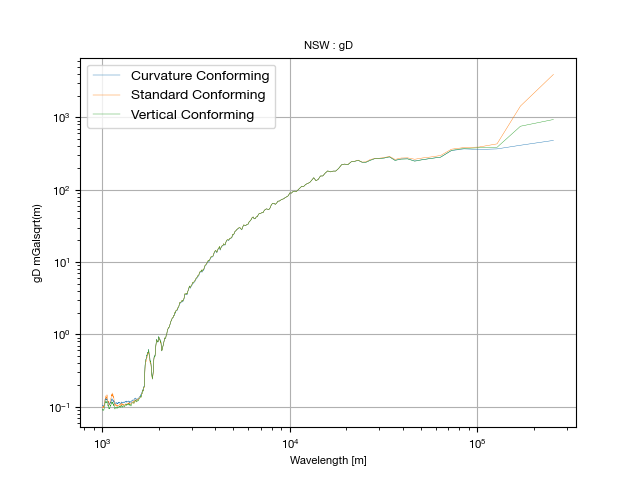

In [38]:
plot_psd([w1, w2, w3], [p1, p2, p3], labels=["Curvature Conforming", "Standard Conforming", "Vertical Conforming", "noise", "BW"], projectname="NSW", zname="gD", zunits="mGal")

In [ ]:
from matplotlib.cbook import get_sample_data
from matplotlib.colors import LightSource

# dem = get_sample_data('jacksboro_fault_dem.npz')
z = x1#dem['elevation']
# -- Optional dx and dy for accurate vertical exaggeration --------------------
# If you need topographically accurate vertical exaggeration, or you don't want
# to guess at what *vert_exag* should be, you'll need to specify the cellsize
# of the grid (i.e. the *dx* and *dy* parameters).  Otherwise, any *vert_exag*
# value you specify will be relative to the grid spacing of your input data
# (in other words, *dx* and *dy* default to 1.0, and *vert_exag* is calculated
# relative to those parameters).  Similarly, *dx* and *dy* are assumed to be in
# the same units as your input z-values.  Therefore, we'll need to convert the
# given dx and dy from decimal degrees to meters.
dx, dy = dem['dx'], dem['dy']
dy = 111200 * dy
dx = 111200 * dx * np.cos(np.radians(dem['ymin']))
# -----------------------------------------------------------------------------

# Shade from the northwest, with the sun 45 degrees from horizontal
ls = LightSource(azdeg=315, altdeg=45)
cmap = plt.cm.gist_earth

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(8, 9))
plt.setp(axs.flat, xticks=[], yticks=[])

# Vary vertical exaggeration and blend mode and plot all combinations
for col, ve in zip(axs.T, [0.1, 1, 10]):
    # Show the hillshade intensity image in the first row
    col[0].imshow(ls.hillshade(z, vert_exag=ve, dx=dx, dy=dy), cmap='gray')

    # Place hillshaded plots with different blend modes in the rest of the rows
    for ax, mode in zip(col[1:], ['hsv', 'overlay', 'soft']):
        rgb = ls.shade(z, cmap=cmap, blend_mode=mode,
                       vert_exag=ve, dx=dx, dy=dy)
        ax.imshow(rgb)

# Label rows and columns
for ax, ve in zip(axs[0], [0.1, 1, 10]):
    ax.set_title(f'{ve}', size=18)
for ax, mode in zip(axs[:, 0], ['Hillshade', 'hsv', 'overlay', 'soft']):
    ax.set_ylabel(mode, size=18)

# Group labels...
axs[0, 1].annotate('Vertical Exaggeration', (0.5, 1), xytext=(0, 30),
                   textcoords='offset points', xycoords='axes fraction',
                   ha='center', va='bottom', size=20)
axs[2, 0].annotate('Blend Mode', (0, 0.5), xytext=(-30, 0),
                   textcoords='offset points', xycoords='axes fraction',
                   ha='right', va='center', size=20, rotation=90)
fig.subplots_adjust(bottom=0.05, right=0.95)

plt.show()